                                                                Progetto: Variational Autoencoder (VAE) su Flowers102

Obiettivo del Progetto

L'obiettivo di questo caso pratico è implementare un Variational Autoencoder (VAE) completo utilizzando PyTorch.

Invece dei classici MNIST o FashionMNIST, utilizzeremo il dataset Flowers102, che presenta immagini a colori di 102 specie di fiori diverse.

Dovrai costruire un'architettura in grado di comprimere queste immagini in uno spazio latente continuo e denso, permettendo non solo la ricostruzione, ma anche la navigazione (interpolazione) e la generazione di nuovi fiori realistici.

** Fasi del Progetto **

* Fase 1: Data Strategy e Preprocessing
    - Carica il dataset Flowers102 (split 'train') tramite torchvision.
    - Applica trasformazioni per ridimensionare le immagini a \(64 \times 64\) e normalizzarle in un range \([0, 1]\).
    - Configura un DataLoader efficiente.
* Fase 2: Architettura del Variational Autoencoder
    Implementa una classe VAE che includa:
        - Encoder: Una serie di blocchi convoluzionali per estrarre feature spaziali, terminando con due rami lineari che producono i vettori \(\mu\) (media) e \(\log(\sigma^2)\) (log-varianza).
        - Reparameterization Trick: Una funzione per campionare \(z\) dallo spazio latente in modo derivabile: \(z = \mu +\sigma \cdot \epsilon\).
        - Decoder: Una rete speculare all'encoder (usando ConvTranspose2d) che parta dal vettore latente \(z\) per ricostruire l'immagine originale \(64 \times 64 \times 3\).

* Fase 3: Definizione della Loss Function (ELBO)
    La funzione di perdita deve essere composta da due termini:
        - Reconstruction Loss: Misura quanto l'immagine ricostruita è simile all'originale (usa MSELoss o BinaryCrossEntropy).
        - KL Divergence: Regolarizza lo spazio latente forzando la distribuzione approssimata \(q(z|x)\) a essere vicina a una normale standard \(\mathcal{N}(0, 1)\).

* Fase 4: Training Loop e KL Annealing
    - Implementa il loop di addestramento.
    - Bonus: Implementa una tecnica di "KL Annealing" (aumentare gradualmente il peso del termine KL durante le prime epoche) per evitare il posterior collapse.
    - Monitora l'andamento delle due componenti della loss.

*Fase 5: Analisi dello Spazio Latente e Generazione
     Ricostruzione: Visualizza una griglia di immagini originali affiancate alle loro ricostruzioni
    Campionamento: Genera nuove immagini campionando vettori \(z\) casuali dalla distribuzione normale standardInterpolazione 
    Latente: Seleziona due immagini del dataset, ottieni i loro vettori latenti (\(z_1, z_2\)) e mostra la trasformazione fluida (walk) tra i due punti.

Requisiti Tecnici
    Linguaggio: Python
    Framework: PyTorch
    Hardware: Supporto per CUDA/MPS se disponibile.

Estetica: Le griglie di output devono essere chiare e ben formattate

Preparazione dell'ambiente

In [18]:
# ==============================================================================
# IMPORT DELLE LIBRERIE
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
import numpy as np

Configurazione

In [2]:
# ==============================================================================
# CONFIGURAZIONE DEL SISTEMA
# ==============================================================================

DEVICE = "" 

LEARNING_RATE = 1e-3

# Dimensione delle immagini.
IMAGE_SIZE = 64 

# Numero di canali delle immagini RGB.
CHANNELS_IMG = 3

# Dimensione dello spazio latente.
Z_DIM = 128

# Numero di immagini elaborate contemporaneamente.
BATCH_SIZE = 64

# Numero di epoche.
NUM_EPOCHS = 40  # I fiori richiedono più epoche per convergere

KL_WEIGHT_MAX = 0.005 

# Numero di epoche durante le quali aumenteremo gradualmente il peso della KL.
ANNEALING_EPOCHS = 10 

L'immagine originale ha 3x64x64=12288 valori
Chiedo all'encoder di rappresentarla in 128 valori

In [3]:
# Ottimizzazione backend
torch.backends.cudnn.benchmark = True

In [4]:
# ==============================================================================
# CONFIGURAZIONE DEL DEVICE
# ==============================================================================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device utilizzato:", DEVICE)

Device utilizzato: cpu


Preprocessing Flowers102
- ridimensionare l'immagine a 64x64 e normalizzarle in [0,1]

In [6]:
# ==============================================================================
# PREPROCESSING DELLE IMMAGINI
# ==============================================================================

transform = transforms.Compose([

    # Tutte le immagini vengono portate a 64x64 pixel.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    # Converte l'immagine PIL in Tensor.
    # I valori dei pixel vengono convertiti nel range [0, 1].
    transforms.ToTensor()
])

Caricamento dataset Flowers102

In [7]:
# ==============================================================================
# CARICAMENTO DATASET FLOWERS102
# ==============================================================================

train_dataset = datasets.Flowers102(root="./data",split="train",download=True,transform=transform)

print("Numero immagini nel training set:", len(train_dataset))

Numero immagini nel training set: 1020


DataLoader
batching, shuffle e caricamento.

In [9]:
# ==============================================================================
# CREAZIONE DEL DATALOADER
# ==============================================================================

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=(DEVICE.type == "cuda"))

Controllo sui dati

In [10]:
# ==============================================================================
# CONTROLLO DI UN BATCH
# ==============================================================================

images, labels = next(iter(train_loader))

print("Shape batch immagini:", images.shape)
print("Shape labels:", labels.shape)

print("Valore minimo pixel:", images.min().item())
print("Valore massimo pixel:", images.max().item())

Shape batch immagini: torch.Size([64, 3, 64, 64])
Shape labels: torch.Size([64])
Valore minimo pixel: 0.0
Valore massimo pixel: 1.0


Visualizzo qualche immagine

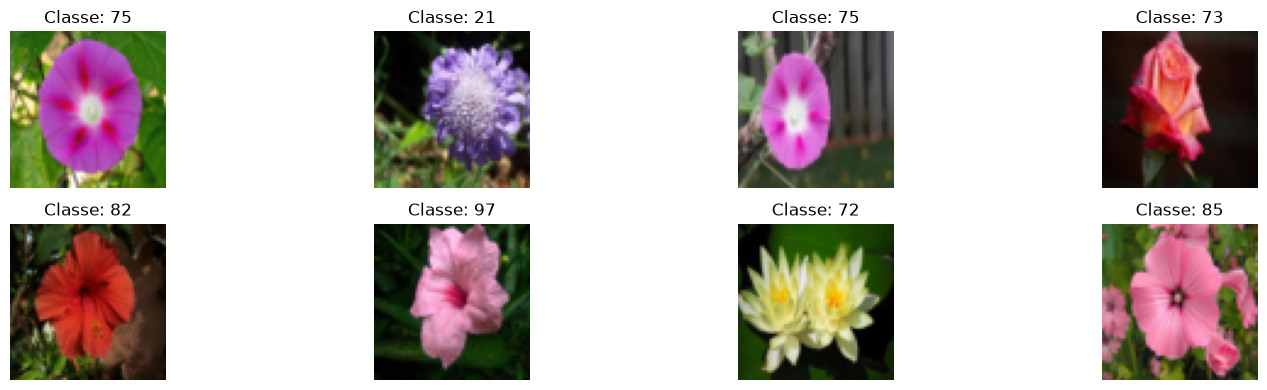

In [11]:
# ==============================================================================
# VISUALIZZAZIONE DI ALCUNE IMMAGINI
# ==============================================================================

images, labels = next(iter(train_loader))

num_images = 8

plt.figure(figsize=(16, 4))
for i in range(num_images):
    #passo da memorizzazione Pytorch [C,H,W] a memorizzazione Matplotlib [H,W,C]
    image = images[i].permute(1, 2, 0)
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Classe: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Costruzione Encoder

Parto da [3,64,64] e voglio arrivare a [256,4,4], utilizzando 4 convoluzioni

In [12]:
kernel_size=4
stride=2
padding=1

Classe VAE

In [25]:
# ==============================================================================
# ARCHITETTURA VARIATIONAL AUTOENCODER
# ==============================================================================

class VAE(nn.Module):

    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        # ======================================================================
        # ENCODER
        # ======================================================================
        self.encoder = nn.Sequential(
            # [B, 3, 64, 64] -> [B, 32, 32, 32]
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=4,stride=2, padding=1),
            nn.ReLU(inplace=True),
            # [B, 32, 32, 32] -> [B, 64, 16, 16]
            nn.Conv2d(32,64,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # [B, 64, 16, 16] -> [B, 128, 8, 8]
            nn.Conv2d(64,128,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # [B, 128, 8, 8] -> [B, 256, 4, 4]
            nn.Conv2d(128,256,kernel_size=4,stride=2,padding=1),

            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # ======================================================================
        # MU E LOG-VARIANCE
        # ======================================================================

        # Dimensione finale dell'encoder:
        # 256 canali x 4 x 4 = 4096 valori
        encoder_output_size = 256 * 4 * 4
        # media mu
        self.fc_mu = nn.Linear(encoder_output_size,latent_dim)
        # log(sigma^2)
        self.fc_logvar = nn.Linear(encoder_output_size,latent_dim)

        # ======================================================================
        # PRIMO LAYER DEL DECODER
        # ======================================================================

        # Riporta il vettore latente da 128 dimensioni a 4096 valori.
        self.decoder_input = nn.Linear(latent_dim,encoder_output_size)

        # ======================================================================
        # DECODER
        # ======================================================================

        # ConvTranspose2d utilizzata per aumentare progressivamente la dimensione delle feature map
        self.decoder = nn.Sequential(
            # [B, 256, 4, 4] -> [B, 128, 8, 8]
            nn.ConvTranspose2d(256,128,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # [B, 128, 8, 8] -> [B, 64, 16, 16]
            nn.ConvTranspose2d(128,64,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # [B, 64, 16, 16] -> [B, 32, 32, 32]
            nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # [B, 32, 32, 32] -> [B, 3, 64, 64]
            nn.ConvTranspose2d(32,3,kernel_size=4,stride=2,padding=1),
            # Riporta l'output nel range [0, 1].
            nn.Sigmoid()
        )


    # ==========================================================================
    # ENCODER
    # ==========================================================================

    def encode(self, x):
        x = self.encoder(x)
        # Da: [B, 256, 4, 4] a: [B, 4096]
        x = torch.flatten(x, start_dim=1)
        # mu e logvar caratteristiche del VAE (non lo era per AE)
        # 'questa immagine appartiene a una distribuzione con questa media e questa varianza'
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    # ==========================================================================
    # REPARAMETERIZATION TRICK
    # ==========================================================================

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        # epsilon viene estratto da N(0,1).
        epsilon = torch.randn_like(std)
        # z = mu + sigma * epsilon
        z = mu + std * epsilon

        return z


    # ==========================================================================
    # DECODE
    # ==========================================================================

    def decode(self, z):

        x = self.decoder_input(z)
        # Da: [B, 4096] a: [B, 256, 4, 4]
        x = x.view(-1,256,4,4)
        x = self.decoder(x)

        return x


    # ==========================================================================
    # FORWARD
    # ==========================================================================

    def forward(self, x):

        # Encoder
        mu, logvar = self.encode(x)
        # Sampling latente
        z = self.reparameterize(mu,logvar)

        # Decoder
        reconstructed = self.decode(z)

        return reconstructed, mu, logvar

In [14]:
# =============================================================================
# 3. LOSS FUNCTION
# =============================================================================
def vae_loss_function(recon_x, x, mu, logvar, kl_weight):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kld_loss, recon_loss, kld_loss


CREAZIONE MODELLO

In [ ]:
# ==============================================================================
# CREAZIONE DEL MODELLO
# ==============================================================================

model = VAE(latent_dim=Z_DIM).to(DEVICE)
print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTran

Controlliamo la shape prima del training

In [28]:
# ==============================================================================
# TEST DELLE DIMENSIONI DEL MODELLO
# ==============================================================================

test_batch = torch.randn(2,3,64,64).to(DEVICE)

with torch.no_grad():
    reconstructed, mu, logvar = model(test_batch)

print("Input:")
print(test_batch.shape)

print("\nMu:")
print(mu.shape)

print("\nLogVar:")
print(logvar.shape)

print("\nRicostruzione:")
print(reconstructed.shape)

Input:
torch.Size([2, 3, 64, 64])

Mu:
torch.Size([2, 128])

LogVar:
torch.Size([2, 128])

Ricostruzione:
torch.Size([2, 3, 64, 64])


Loss del VAE

In [ ]:
# ==============================================================================
# LOSS FUNCTION DEL VAE
# ==============================================================================

def vae_loss(reconstructed,original,mu,logvar,kl_weight=1.0):

    batch_size_current = original.size(0)

    # ======================================================================
    # RECONSTRUCTION LOSS
    # ======================================================================

    reconstruction_loss = F.mse_loss(reconstructed,original,reduction="sum")

    # Calcoliamo una media per immagine.
    reconstruction_loss = (reconstruction_loss / batch_size_current)

    # ======================================================================
    # KL DIVERGENCE
    # ======================================================================

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Media per immagine.
    kl_loss = (kl_loss / batch_size_current)

    # ======================================================================
    # LOSS TOTALE
    # ======================================================================

    total_loss = (reconstruction_loss + kl_weight * kl_loss)

    return (total_loss, reconstruction_loss, kl_loss)

OPTIMIZER

In [30]:
# ==============================================================================
# OPTIMIZER
# ==============================================================================

optimizer = optim.Adam(model.parameters(),lr=LEARNING_RATE)

VARIABILI PER REGISTRARE L'ANDAMENTO

In [31]:
# ==============================================================================
# STORICO DEL TRAINING
# ==============================================================================

history_total = []
history_reconstruction = []
history_kl = []
history_kl_weight = []

Training loop completo

In [ ]:
# ==============================================================================
# TRAINING DEL VARIATIONAL AUTOENCODER
# ==============================================================================

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()

    epoch_total_loss = 0.0
    epoch_reconstruction_loss = 0.0
    epoch_kl_loss = 0.0

    total_samples = 0

    # ==========================================================================
    # KL ANNEALING
    # ==========================================================================

    kl_weight = min(1.0, epoch / ANNEALING_EPOCHS)

    # ==========================================================================
    # LOOP SUI BATCH
    # ==========================================================================

    for images, _ in train_loader:
        images = images.to(DEVICE)
        current_batch_size = images.size(0)
        # AZZERAMENTO DEI GRADIENTI
        optimizer.zero_grad()
        # FORWARD PASS
        reconstructed, mu, logvar = model(images)
        # CALCOLO DELLA LOSS-
        loss, reconstruction_loss, kl_loss = vae_loss(reconstructed,images,mu,logvar,kl_weight=kl_weight)
        # BACKPROPAGATION
        loss.backward()
        # AGGIORNAMENTO DEI PESI
        optimizer.step()
        # ACCUMULO DELLE LOSS
        epoch_total_loss += (loss.item() * current_batch_size)
        epoch_reconstruction_loss += (reconstruction_loss.item() * current_batch_size)
        epoch_kl_loss += (kl_loss.item() * current_batch_size)
        total_samples += current_batch_size

    # ==========================================================================
    # MEDIA DELL'EPOCA
    # ==========================================================================

    avg_total_loss = (epoch_total_loss / total_samples)
    avg_reconstruction_loss = (epoch_reconstruction_loss / total_samples)
    avg_kl_loss = (epoch_kl_loss / total_samples)

    # ==========================================================================
    # SALVATAGGIO NELLO STORICO
    # ==========================================================================

    history_total.append(avg_total_loss)
    history_reconstruction.append(avg_reconstruction_loss)
    history_kl.append(avg_kl_loss)
    history_kl_weight.append(kl_weight)

    # ==========================================================================
    # OUTPUT
    # ==========================================================================

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"| Total Loss: {avg_total_loss:.4f} "
        f"| Reconstruction: {avg_reconstruction_loss:.4f} "
        f"| KL: {avg_kl_loss:.4f} "
        f"| KL Weight: {kl_weight:.2f}"
    )

Epoch [01/40] | Total Loss: 523.7247 | Reconstruction: 508.1200 | KL: 156.0469 | KL Weight: 0.10
Epoch [02/40] | Total Loss: 448.8035 | Reconstruction: 420.8160 | KL: 139.9371 | KL Weight: 0.20
Epoch [03/40] | Total Loss: 422.6658 | Reconstruction: 389.5163 | KL: 110.4983 | KL Weight: 0.30
Epoch [04/40] | Total Loss: 410.9158 | Reconstruction: 370.4454 | KL: 101.1761 | KL Weight: 0.40
Epoch [05/40] | Total Loss: 398.7002 | Reconstruction: 354.5402 | KL: 88.3200 | KL Weight: 0.50
Epoch [06/40] | Total Loss: 391.5585 | Reconstruction: 344.0239 | KL: 79.2243 | KL Weight: 0.60
Epoch [07/40] | Total Loss: 384.7544 | Reconstruction: 331.2447 | KL: 76.4424 | KL Weight: 0.70
Epoch [08/40] | Total Loss: 379.1382 | Reconstruction: 322.0361 | KL: 71.3776 | KL Weight: 0.80
Epoch [09/40] | Total Loss: 375.2961 | Reconstruction: 312.8001 | KL: 69.4399 | KL Weight: 0.90
Epoch [10/40] | Total Loss: 368.2792 | Reconstruction: 303.8705 | KL: 64.4087 | KL Weight: 1.00
Epoch [11/40] | Total Loss: 364.8998

Grafico della Loss

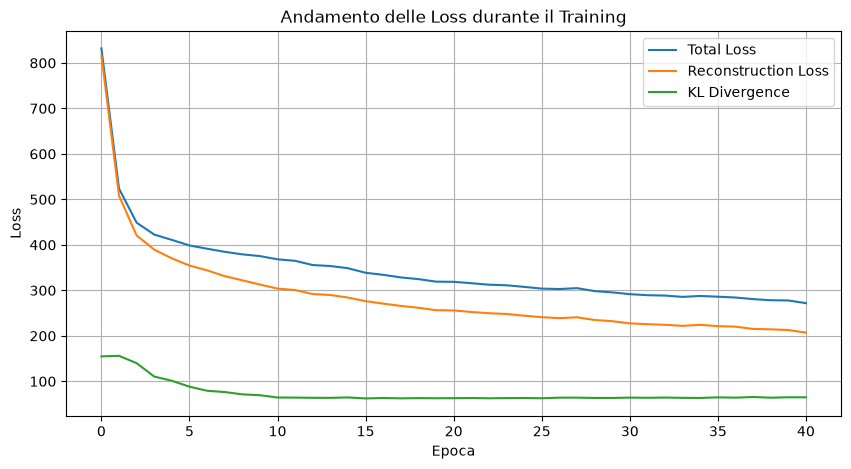

In [ ]:
# ==============================================================================
# GRAFICO LOSS
# ==============================================================================

plt.figure(figsize=(10, 5))
plt.plot(history_total,label="Total Loss")
plt.plot(history_reconstruction,label="Reconstruction Loss")
plt.plot(history_kl,label="KL Divergence")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Andamento delle Loss durante il Training")
plt.legend()
plt.grid()
plt.show()

Salviamo il modello

In [36]:
# ==============================================================================
# SALVATAGGIO DEL MODELLO
# ==============================================================================

torch.save({"model_state_dict": model.state_dict(),"latent_dim": Z_DIM,"image_size": IMAGE_SIZE},"vae_flowers102.pth")

print("Modello salvato correttamente.")

Modello salvato correttamente.


Ricostruzione

In [37]:
# ==============================================================================
# RICOSTRUZIONE DELLE IMMAGINI
# ==============================================================================

model.eval()

images, _ = next(iter(train_loader))
images = images[:8].to(DEVICE)
with torch.no_grad():
    mu, logvar = model.encode(images)
    # Per una ricostruzione stabile utilizziamo la media.
    z = mu
    reconstructed = model.decode(z)


images = images.cpu()

reconstructed = reconstructed.cpu()

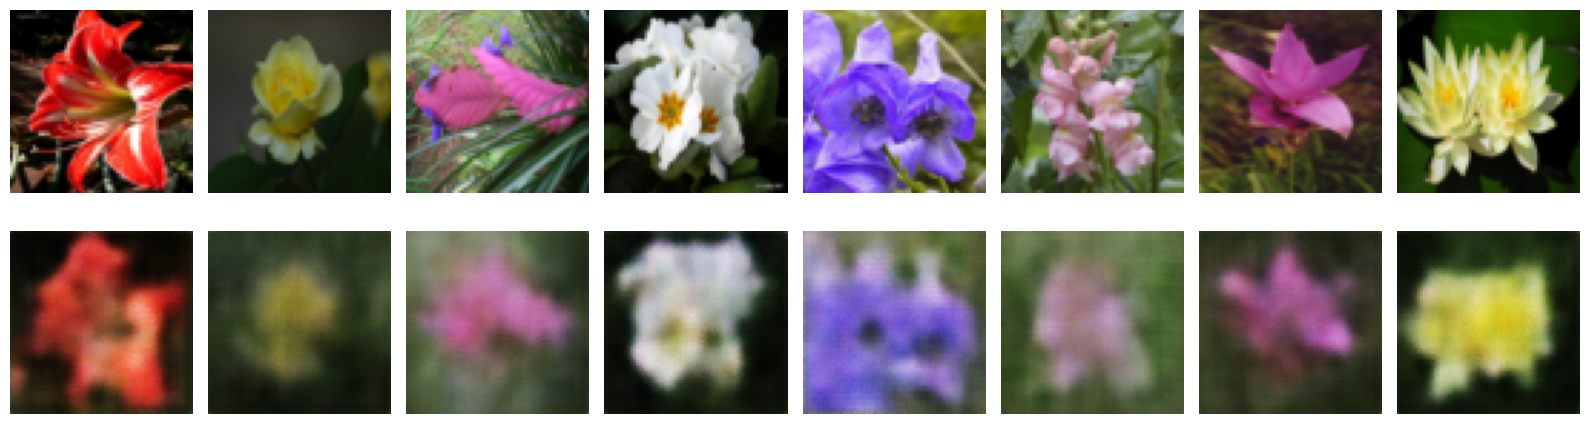

In [ ]:
# ==============================================================================
# CONFRONTO ORIGINALI VS RICOSTRUZIONI
# ==============================================================================

num_images = 8
plt.figure(figsize=(16, 5))

for i in range(num_images):

    # --------------------------------------------------------------------------
    # IMMAGINE ORIGINALE
    # --------------------------------------------------------------------------
    original = images[i].permute(1,2,0)

    plt.subplot(2,num_images,i + 1)
    plt.imshow(original)
    plt.axis("off")
    if i == 0:
        plt.ylabel("Originali")

    # --------------------------------------------------------------------------
    # IMMAGINE RICOSTRUITA
    # --------------------------------------------------------------------------
    reconstruction = reconstructed[i].permute(1,2,0)

    plt.subplot(2,num_images,num_images + i + 1)
    plt.imshow(reconstruction)
    plt.axis("off")
    if i == 0:
        plt.ylabel("Ricostruzioni")

plt.tight_layout()
plt.show()

Generazione nuovi fiori

In [39]:
# ==============================================================================
# GENERAZIONE DI NUOVE IMMAGINI
# ==============================================================================

model.eval()

num_samples = 16
with torch.no_grad():

    # Campionamento dalla normale standard.
    z = torch.randn(num_samples,Z_DIM,device=DEVICE)
    generated_images = model.decode(z)

generated_images = generated_images.cpu()

Visualizzazione fiori generati

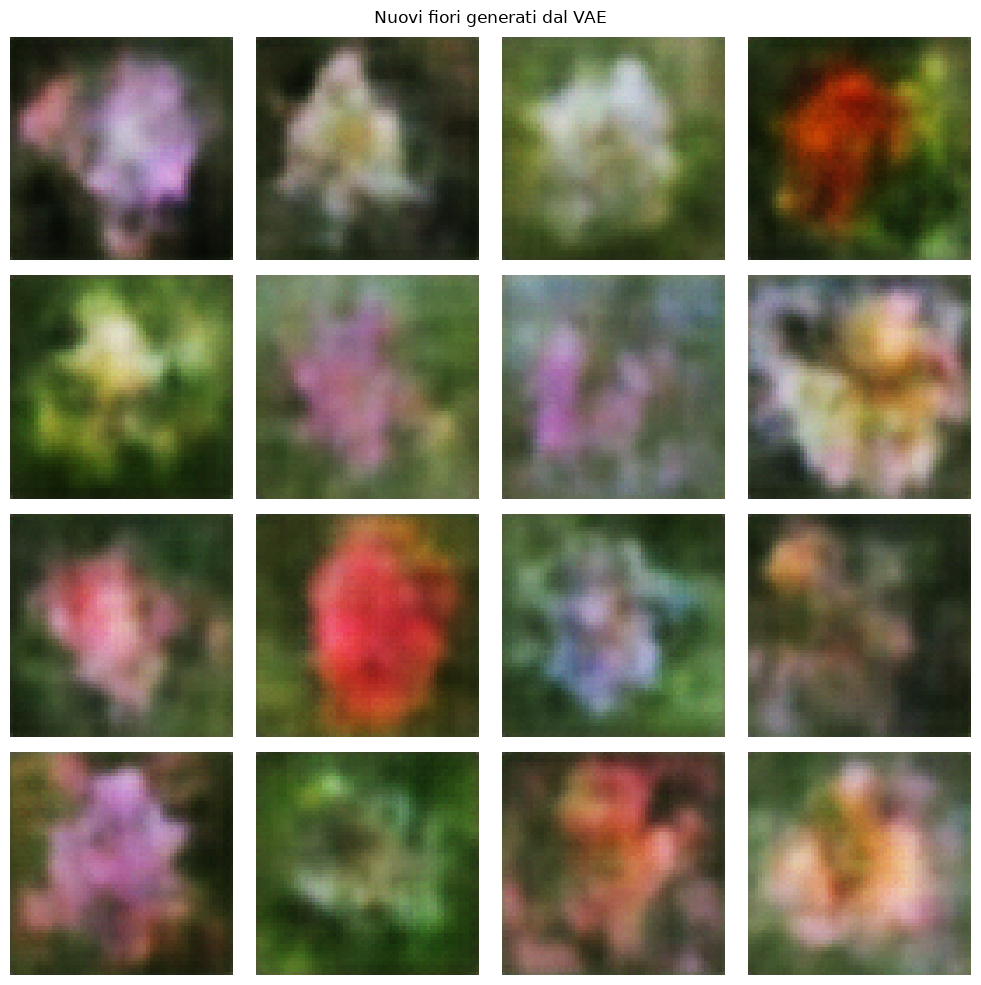

In [41]:
# ==============================================================================
# VISUALIZZAZIONE DELLE IMMAGINI GENERATE
# ==============================================================================

plt.figure(figsize=(10, 10))
for i in range(num_samples):
    image = generated_images[i].permute(1,2,0)
    plt.subplot(4,4,i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Nuovi fiori generati dal VAE")
plt.tight_layout()
plt.show()

Interpolazione spazio latente.

In [ ]:
# ==============================================================================
# SELEZIONE DI DUE FIORI DI CLASSI DIFFERENTI
# ==============================================================================

index_1 = 0
image_1, label_1 = train_dataset[index_1]
index_2 = None
for i in range(1, len(train_dataset)):
    image_candidate, label_candidate = train_dataset[i]
    if label_candidate != label_1:
        index_2 = i
        break

image_2, label_2 = train_dataset[index_2]

print("Prima classe:", label_1)
print("Seconda classe:", label_2)

Prima classe: 0
Seconda classe: 1


Otteniamo le rappresentazioni latenti

In [43]:
# ==============================================================================
# ENCODING DELLE DUE IMMAGINI
# ==============================================================================

image_1_batch = image_1.unsqueeze(0).to(DEVICE)
image_2_batch = image_2.unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():
    mu_1, logvar_1 = model.encode(image_1_batch)
    mu_2, logvar_2 = model.encode(image_2_batch)

Interpolazione

In [46]:
# ==============================================================================
# INTERPOLAZIONE LATENTE
# ==============================================================================

steps = 10


alphas = torch.linspace(0,1,steps,device=DEVICE)
latent_vectors = []
for alpha in alphas:
    z = ((1 - alpha) * mu_1 + alpha * mu_2)
    latent_vectors.append(z)

latent_vectors = torch.cat(latent_vectors,dim=0)

print("Shape vettori interpolati:",latent_vectors.shape)

Shape vettori interpolati: torch.Size([10, 128])


Decodifichiamo l'interpolazione

In [47]:
# ==============================================================================
# DECODING DELLA WALK LATENTE
# ==============================================================================

with torch.no_grad():
    interpolated_images = model.decode(latent_vectors)

interpolated_images = interpolated_images.cpu()

Visualizziamo la trasformazione

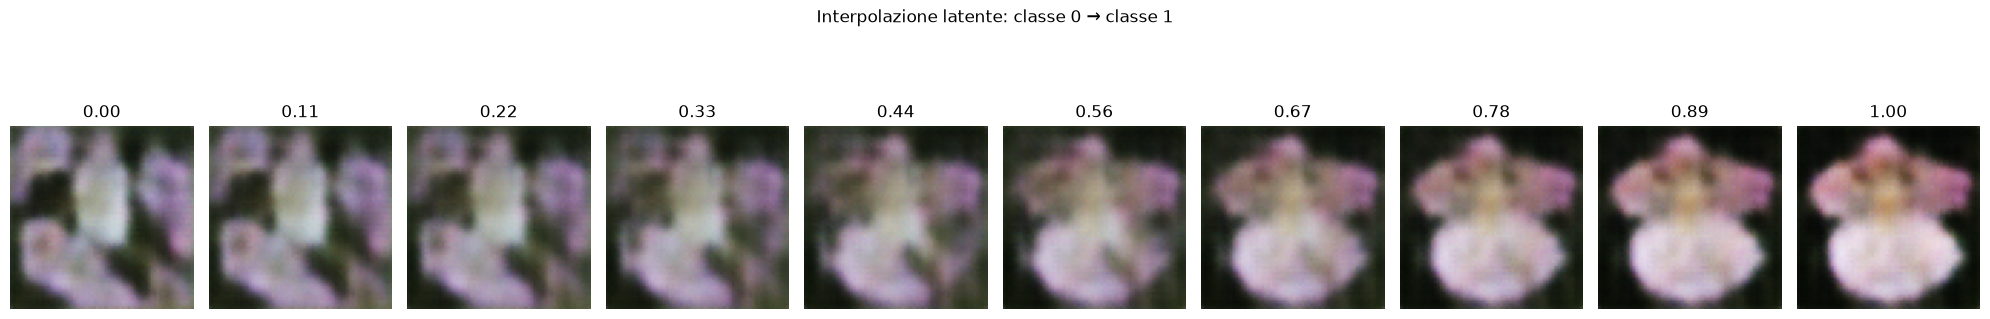

In [ ]:
# ==============================================================================
# VISUALIZZAZIONE DELL'INTERPOLAZIONE
# ==============================================================================

plt.figure(figsize=(20, 4))
for i in range(steps):
    image = interpolated_images[i].permute(1,2,0)
    plt.subplot(1,steps,i + 1)
    plt.imshow(image)
    plt.title(f"{i / (steps - 1):.2f}")
    plt.axis("off")

plt.suptitle(f"Interpolazione latente: classe {label_1} → classe {label_2}")
plt.tight_layout()

plt.show()